In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import cv2
from PIL import Image

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CelebA

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cpu


In [2]:
from pathlib import Path
root = Path("/Users/fonseca2@qut.edu.au/Projects/IFQ680_s1_2026/Week_4/Assesment/data/celeba")
assert root.exists(), "Dataset not found—run download=True"
assert (root / "img_align_celeba").is_dir()
for f in ["list_attr_celeba.txt", "list_eval_partition.txt"]:
    print(root / f); print((root / f).exists());
assert all((root / f).exists() for f in ["list_attr_celeba.txt", "list_eval_partition.txt"])
print(f"Images: {len(list((root / 'img_align_celeba').glob('*.jpg')))}")



# Load CelebA dataset
celeba_dataset_train = CelebA(root=root.parent, split='train', target_type='attr', transform=None, download=False)
celeba_dataset_valid = CelebA(root=root.parent, split='valid', target_type='attr', transform=None, download=False)
celeba_dataset_test = CelebA(root=root.parent, split='test', target_type='attr', transform=None, download=False)
print(f"Dataset loaded: {len(celeba_dataset_train)} images")
print(f"Dataset loaded: {len(celeba_dataset_valid)} images")
print(f"Dataset loaded: {len(celeba_dataset_test)} images")

/Users/fonseca2@qut.edu.au/Projects/IFQ680_s1_2026/Week_4/Assesment/data/celeba/list_attr_celeba.txt
True
/Users/fonseca2@qut.edu.au/Projects/IFQ680_s1_2026/Week_4/Assesment/data/celeba/list_eval_partition.txt
True
Images: 202599
Dataset loaded: 162770 images
Dataset loaded: 19867 images
Dataset loaded: 19962 images


In [3]:
# Print the name and index of each attribute in the CelebA dataset
for idx, attr_name in enumerate(celeba_dataset_train.attr_names):
    print(f"Index {idx}: {attr_name}")

Index 0: 5_o_Clock_Shadow
Index 1: Arched_Eyebrows
Index 2: Attractive
Index 3: Bags_Under_Eyes
Index 4: Bald
Index 5: Bangs
Index 6: Big_Lips
Index 7: Big_Nose
Index 8: Black_Hair
Index 9: Blond_Hair
Index 10: Blurry
Index 11: Brown_Hair
Index 12: Bushy_Eyebrows
Index 13: Chubby
Index 14: Double_Chin
Index 15: Eyeglasses
Index 16: Goatee
Index 17: Gray_Hair
Index 18: Heavy_Makeup
Index 19: High_Cheekbones
Index 20: Male
Index 21: Mouth_Slightly_Open
Index 22: Mustache
Index 23: Narrow_Eyes
Index 24: No_Beard
Index 25: Oval_Face
Index 26: Pale_Skin
Index 27: Pointy_Nose
Index 28: Receding_Hairline
Index 29: Rosy_Cheeks
Index 30: Sideburns
Index 31: Smiling
Index 32: Straight_Hair
Index 33: Wavy_Hair
Index 34: Wearing_Earrings
Index 35: Wearing_Hat
Index 36: Wearing_Lipstick
Index 37: Wearing_Necklace
Index 38: Wearing_Necktie
Index 39: Young
Index 40: 


In [8]:
# Attribute matrix: rows = images, columns = attributes
# attribute index 25 no_beard
eyeglasses_idx = celeba_dataset_train.attr_names.index('Eyeglasses')
male_idx = celeba_dataset_train.attr_names.index('Male')

# Define split configurations
split_configs = [
    {
        'dataset': celeba_dataset_train,
        'num_samples': 300,
        'name': 'train'
    },
    {
        'dataset': celeba_dataset_valid,
        'num_samples': 150,
        'name': 'valid'
    },
    {
        'dataset': celeba_dataset_test,
        'num_samples': 150,
        'name': 'test'
    },
]

output_dir = Path("Case2Dataset")
for cfg in split_configs:
    dataset = cfg['dataset']
    num_samples = cfg['num_samples']
    
    eyeglasses = dataset.attr[:, eyeglasses_idx].numpy().astype(bool)
    man = dataset.attr[:, male_idx].numpy().astype(bool)

    
    if cfg['name'] == 'test':
        positive_indices = np.random.choice(np.where(eyeglasses & ~man)[0], size=num_samples, replace=False).tolist()
        negative_indices = np.random.choice(np.where(~eyeglasses & man)[0], size=num_samples, replace=False).tolist()
        
    elif cfg['name'] == 'valid':    
        positive_indices = np.random.choice(np.where(eyeglasses & man)[0], size=num_samples, replace=False).tolist()
        negative_indices = np.random.choice(np.where(~eyeglasses & ~man)[0], size=num_samples, replace=False).tolist()    
    else: 
        # train   
        positive_indices = np.random.choice(np.where(eyeglasses & man)[0], size=num_samples, replace=False).tolist()
        negative_indices = np.random.choice(np.where(~eyeglasses & ~man)[0], size=num_samples, replace=False).tolist()

    positive_output_dir = output_dir / cfg['name'] / "positive"
    positive_output_dir.mkdir(parents=True, exist_ok=True)
    for idx in positive_indices:
        img, _ = dataset[idx]
        img.save(positive_output_dir / f"{idx}.jpg")

    negative_output_dir = output_dir / cfg['name'] / "negative"
    negative_output_dir.mkdir(parents=True, exist_ok=True)
    for idx in negative_indices:
        img, _ = dataset[idx]
        img.save(negative_output_dir / f"{idx}.jpg")


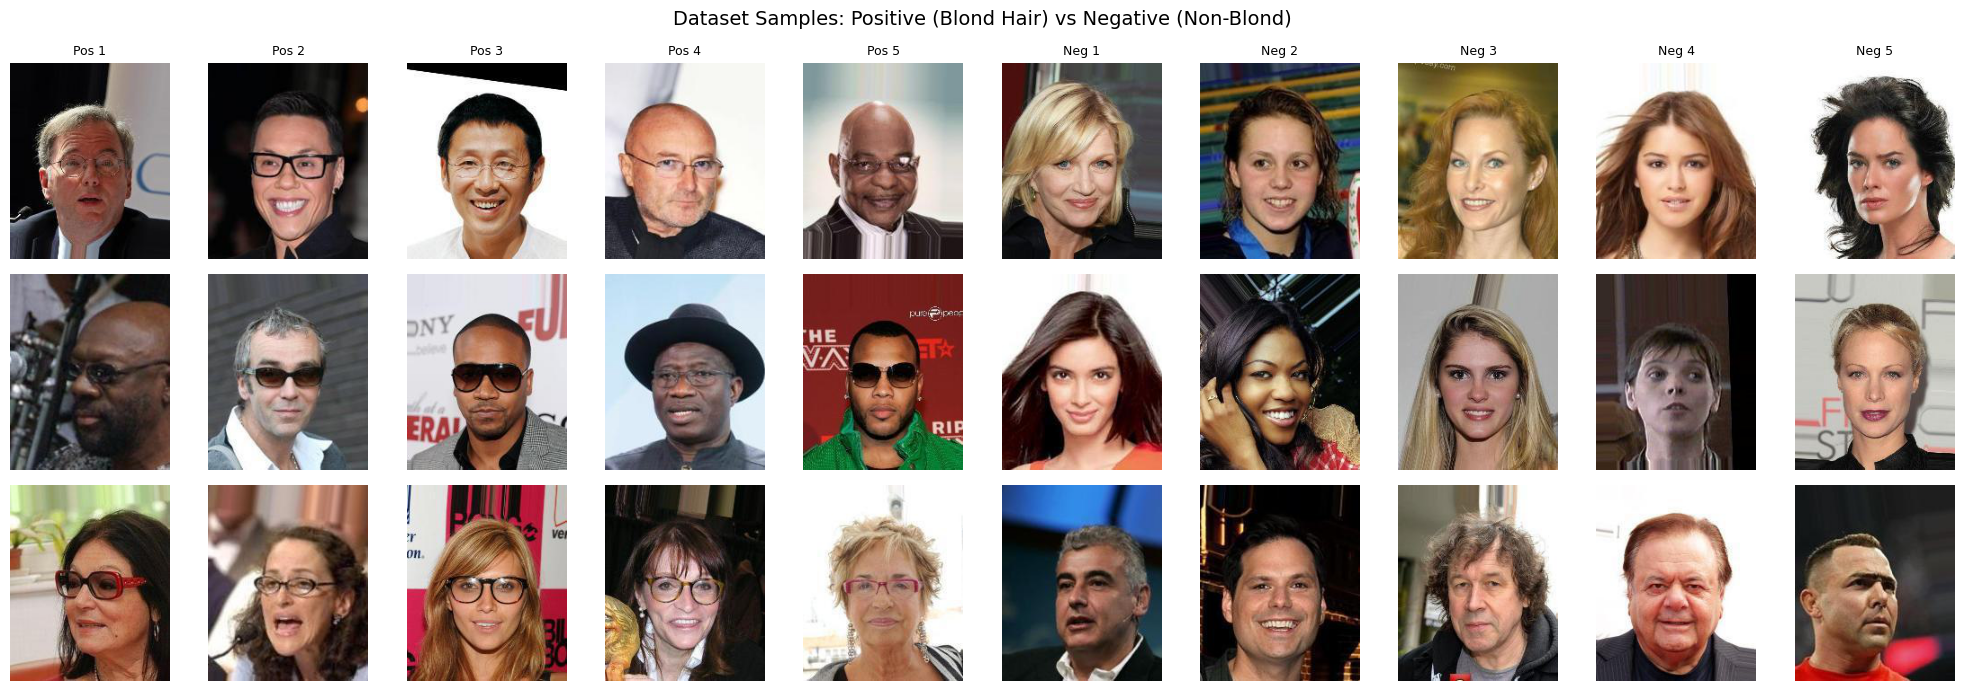

In [9]:
fig, axes = plt.subplots(3, 10, figsize=(20, 7))

splits = ['train', 'valid', 'test']

for row, split in enumerate(splits):
    pos_dir = output_dir / split / "positive"
    neg_dir = output_dir / split / "negative"
    
    pos_images = sorted(pos_dir.glob("*.jpg"))[:5]
    neg_images = sorted(neg_dir.glob("*.jpg"))[:5]
    
    for col, img_path in enumerate(pos_images):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f"Pos {col+1}", fontsize=9)
    
    for col, img_path in enumerate(neg_images):
        img = Image.open(img_path)
        axes[row, col + 5].imshow(img)
        axes[row, col + 5].axis('off')
        if row == 0:
            axes[row, col + 5].set_title(f"Neg {col+1}", fontsize=9)
    
    axes[row, 0].set_ylabel(split, fontsize=12, rotation=90, labelpad=10)
    axes[row, 0].yaxis.set_visible(True)

plt.suptitle("Dataset Samples: Positive (Blond Hair) vs Negative (Non-Blond)", fontsize=14)
plt.tight_layout()
plt.show()